#                         Title
## Cybersecurity Attack Detection Using Data Preprocessing, PCA, and Feature Selection on CICIDS2017 Dataset

# Problem Statement

### The rapid growth of internet services, cloud computing, IoT devices, and online communication has significantly increased the number of cyber attacks such as Distributed Denial of Service (DDoS) attacks, malware, phishing, and network intrusions. Traditional security systems often fail to detect complex and large-scale cyber threats efficiently due to the high volume, velocity, and complexity of network traffic data. Real-world cybersecurity datasets are highly imbalanced and contain missing values, noise, redundant information, and outliers, which make accurate attack detection difficult. Therefore, there is a need for effective data preprocessing, visualization, dimensionality reduction, feature engineering, and feature selection techniques to improve the quality of cybersecurity data and identify the most important network traffic features responsible for attack detection. This project focuses on analyzing the CICIDS2017 cybersecurity dataset using preprocessing and analytical techniques to better understand attack patterns and support the development of efficient intrusion detection systems.

# Introduction 
#### Cybersecurity has become one of the most critical areas in the modern digital world due to the rapid increase in internet usage, cloud computing, IoT devices, online banking, and digital communication systems. Organizations and individuals are continuously exposed to cyber threats such as malware attacks, phishing attacks, ransomware, Distributed Denial of Service (DDoS) attacks, and unauthorized network intrusions. These attacks can lead to financial loss, data leakage, system failures, and privacy violations

#### Traditional security systems are often unable to handle the increasing complexity and volume of cyber attacks. Therefore, Machine Learning and Data Analytics techniques are widely used for detecting malicious network activities and identifying attack patterns.

#### Real-world cybersecurity datasets are usually large, noisy, imbalanced, and contain missing values and outliers. Proper preprocessing and dimensionality reduction techniques are necessary before building machine learning models.

#### In this project, the CICIDS2017 cybersecurity dataset is analyzed using various preprocessing and analytical techniques such as missing value handling, outlier detection, visualization, correlation analysis, Principal Component Analysis (PCA), feature engineering, and feature selection. The project helps in understanding network traffic behavior and identifying the most important features responsible for cyber attack detection.

# About the dataset
### The CICIDS2017 dataset is a real-world cybersecurity dataset developed by the Canadian Institute for Cybersecurity. The dataset contains both normal network traffic and malicious traffic generated under controlled conditions.
## The selected file mainly contains:

## BENIGN traffic
## DDoS attack traffic

## The dataset is highly suitable for machine learning and deep learning applications related to intrusion detection systems and cyber attack classification.

### Data loading is the initial step in data analysis where the dataset is imported into the Python environment using the Pandas library. The dataset is loaded into a DataFrame structure for preprocessing and analysis.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy import stats
import warnings

# Interpretation

### The CICIDS2017 dataset was successfully loaded into the DataFrame. The dataset contains large-scale cybersecurity traffic data with multiple numerical and categorical features representing network flow behavior.

### Real-world datasets often contain noisy data, duplicate records, infinite values, and inconsistent entries. Data cleaning improves data quality by removing unwanted records and correcting invalid values.

In [3]:
data = pd.read_csv(r"/Users/admiin/Downloads/copy/DA&DP project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [5]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


# Interpretation

### During preprocessing, duplicate rows, missing values, and infinite values were identified and removed or replaced appropriately. This improved dataset consistency and ensured better model performance.

# Handle Missing Values
### Missing values occur when some observations do not contain complete information. Machine learning algorithms cannot process NaN values directly; therefore, missing values must be handled using techniques such as:

## Mean imputation
## Median imputation
## Mode replacement
## Row deletion

In [7]:
# 4. MISSING VALUES

print("\n" + "="*70)
print("  MISSING VALUES")
print("="*70 + "\n")

print("Missing values count:\n", df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

df_clean = df.dropna().copy()

# Impute suspicious zero values for continuous features where zero is not a valid measurement
zero_impute_cols = [
    'Flow Duration',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]

for col in zero_impute_cols:
    if col not in df_clean.columns:
        continue
    zero_mask = df_clean[col] == 0
    if not zero_mask.any():
        continue
    nonzero_values = df_clean.loc[~zero_mask, col]
    if nonzero_values.empty:
        continue
    fill_value = nonzero_values.median()
    if pd.api.types.is_integer_dtype(df_clean[col].dtype) and not float(fill_value).is_integer():
        df_clean[col] = df_clean[col].astype('float64')
    df_clean.loc[zero_mask, col] = fill_value
    print(f"Filled {zero_mask.sum()} zero values in '{col}' with median {fill_value}")

print(f"\nOriginal shape: {df.shape}")
print(f"After removing missing: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")


  MISSING VALUES

Missing values count:
  Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

Total missing: 4
Filled 5418 zero values in 'Total Length of Fwd Packets' with median 30.0
Filled 59679 zero values in 'Bwd Packet Length Max' with median 2920.0
Filled 5026 zero values in 'Flow Bytes/s' with median 1415.511648
Filled 31541 zero values in 'Fwd IAT Total' with median 213832.0
Filled 72773 zero values in 'Bwd IAT Total' with median 589444.0
Filled 32 zero values in 'Fwd Packets/s' with median 2.316362631
Filled 587 zero values in 'Init_Win_bytes_forward' with median 256.0
Filled 145536 zero values in 'Active Mean' with median 8163.0
Filled 145477 z

# Interpretation

### The dataset contained missing values in certain network traffic features. These missing values were handled using appropriate statistical methods to prevent errors during analysis and model training.

# Checking Skewness of the data for analysis

In [8]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

skewness_values = df_clean[numeric_cols].skew()
print("Skewness values (first 10):\n")
print(skewness_values.head(10))

Skewness values (first 10):

 Destination Port                1.948131
 Flow Duration                   1.941970
 Total Fwd Packets              59.636533
 Total Backward Packets         66.211268
Total Length of Fwd Packets      7.523046
 Total Length of Bwd Packets    69.596665
 Fwd Packet Length Max           4.087974
 Fwd Packet Length Min           8.040547
 Fwd Packet Length Mean          3.314483
 Fwd Packet Length Std           4.229443
dtype: float64


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/nanops.py:1248: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


# OUTLIER DETECTION
## Outliers are abnormal observations that significantly differ from the majority of the data. In cybersecurity datasets, outliers often indicate suspicious traffic or attack behavior.

### Common methods used for outlier detection include:

#### Interquartile Range (IQR)
#### Z-score analysis
####  Boxplot visualization

 Destination Port: 88791 outliers (39.33%)
 Flow Duration: 37465 outliers (16.60%)
 Total Fwd Packets: 8705 outliers (3.86%)
 Total Backward Packets: 7026 outliers (3.11%)


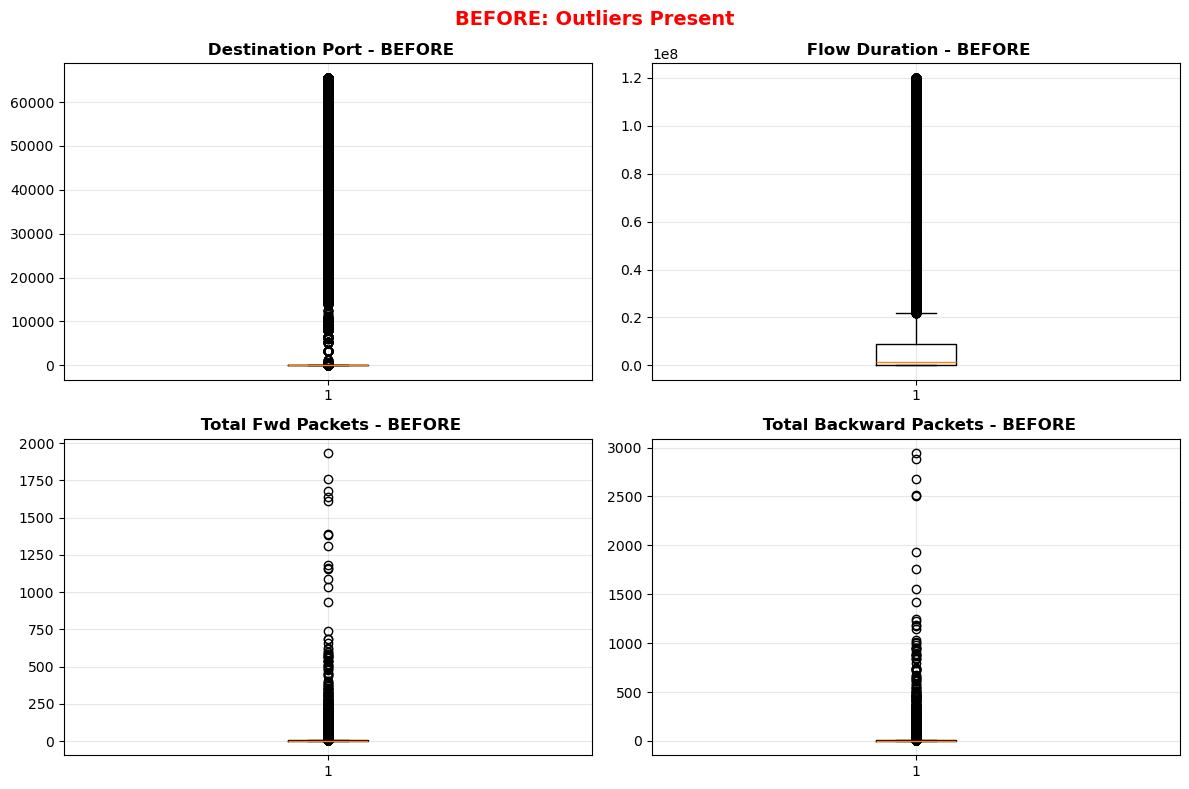

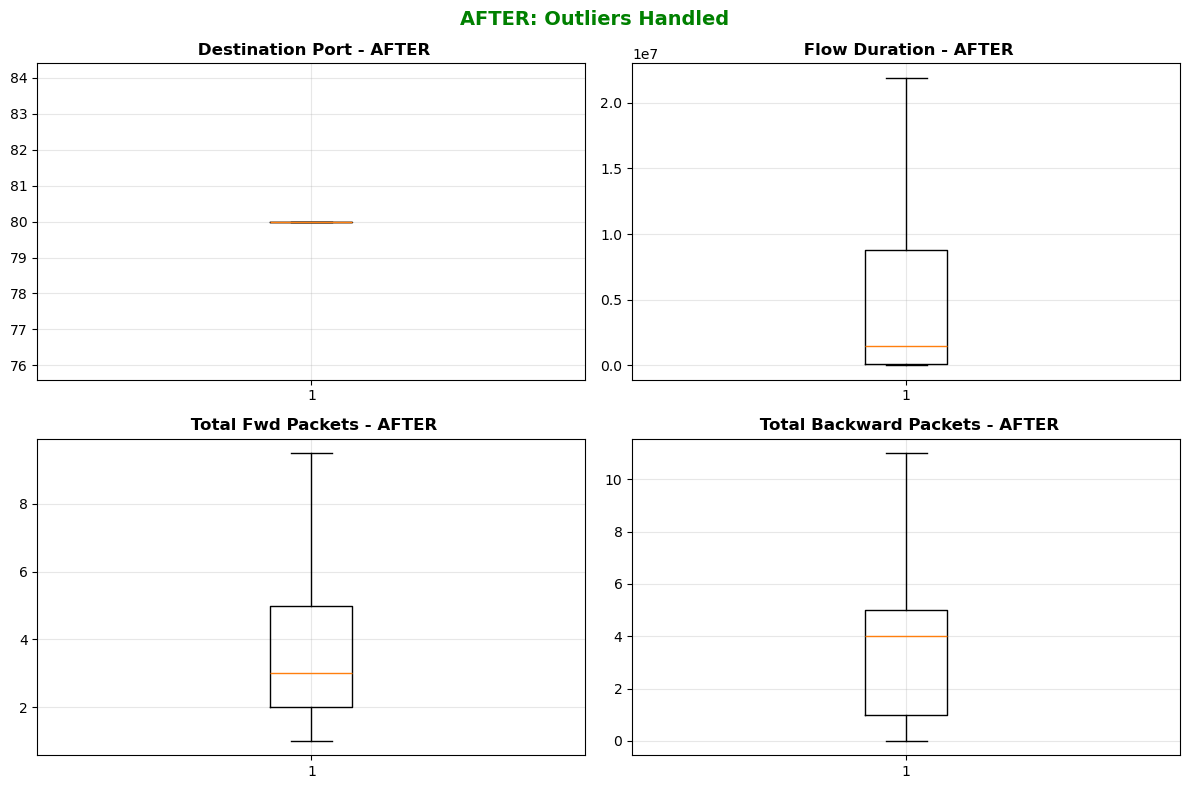


✓ Outliers handled (capped to IQR bounds)
Shape: (225741, 79)


In [9]:
# 6. OUTLIER DETECTION & HANDLING (BEFORE & AFTER)

# Detect outliers for first 4 columns
Q1_col0 = df_clean[numeric_cols[0]].quantile(0.25)
Q3_col0 = df_clean[numeric_cols[0]].quantile(0.75)
IQR_col0 = Q3_col0 - Q1_col0
outliers_col0 = df_clean[(df_clean[numeric_cols[0]] < Q1_col0 - 1.5*IQR_col0) | (df_clean[numeric_cols[0]] > Q3_col0 + 1.5*IQR_col0)]
print(f"{numeric_cols[0]}: {len(outliers_col0)} outliers ({len(outliers_col0)/len(df_clean)*100:.2f}%)")

Q1_col1 = df_clean[numeric_cols[1]].quantile(0.25)
Q3_col1 = df_clean[numeric_cols[1]].quantile(0.75)
IQR_col1 = Q3_col1 - Q1_col1
outliers_col1 = df_clean[(df_clean[numeric_cols[1]] < Q1_col1 - 1.5*IQR_col1) | (df_clean[numeric_cols[1]] > Q3_col1 + 1.5*IQR_col1)]
print(f"{numeric_cols[1]}: {len(outliers_col1)} outliers ({len(outliers_col1)/len(df_clean)*100:.2f}%)")

Q1_col2 = df_clean[numeric_cols[2]].quantile(0.25)
Q3_col2 = df_clean[numeric_cols[2]].quantile(0.75)
IQR_col2 = Q3_col2 - Q1_col2
outliers_col2 = df_clean[(df_clean[numeric_cols[2]] < Q1_col2 - 1.5*IQR_col2) | (df_clean[numeric_cols[2]] > Q3_col2 + 1.5*IQR_col2)]
print(f"{numeric_cols[2]}: {len(outliers_col2)} outliers ({len(outliers_col2)/len(df_clean)*100:.2f}%)")

Q1_col3 = df_clean[numeric_cols[3]].quantile(0.25)
Q3_col3 = df_clean[numeric_cols[3]].quantile(0.75)
IQR_col3 = Q3_col3 - Q1_col3
outliers_col3 = df_clean[(df_clean[numeric_cols[3]] < Q1_col3 - 1.5*IQR_col3) | (df_clean[numeric_cols[3]] > Q3_col3 + 1.5*IQR_col3)]
print(f"{numeric_cols[3]}: {len(outliers_col3)} outliers ({len(outliers_col3)/len(df_clean)*100:.2f}%)")

# BEFORE boxplots
plt.figure(figsize=(12, 8))
plt.suptitle('BEFORE: Outliers Present', fontsize=14, fontweight='bold', color='red')
plt.subplot(2, 2, 1)
plt.boxplot(df_clean[numeric_cols[0]])
plt.title(f'{numeric_cols[0]} - BEFORE', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.boxplot(df_clean[numeric_cols[1]])
plt.title(f'{numeric_cols[1]} - BEFORE', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.boxplot(df_clean[numeric_cols[2]])
plt.title(f'{numeric_cols[2]} - BEFORE', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.boxplot(df_clean[numeric_cols[3]])
plt.title(f'{numeric_cols[3]} - BEFORE', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Handle outliers - cap to IQR bounds
df_no_outliers = df_clean.copy()
df_no_outliers[numeric_cols[0]] = df_no_outliers[numeric_cols[0]].clip(Q1_col0 - 1.5*IQR_col0, Q3_col0 + 1.5*IQR_col0)
df_no_outliers[numeric_cols[1]] = df_no_outliers[numeric_cols[1]].clip(Q1_col1 - 1.5*IQR_col1, Q3_col1 + 1.5*IQR_col1)
df_no_outliers[numeric_cols[2]] = df_no_outliers[numeric_cols[2]].clip(Q1_col2 - 1.5*IQR_col2, Q3_col2 + 1.5*IQR_col2)
df_no_outliers[numeric_cols[3]] = df_no_outliers[numeric_cols[3]].clip(Q1_col3 - 1.5*IQR_col3, Q3_col3 + 1.5*IQR_col3)

# AFTER boxplots
plt.figure(figsize=(12, 8))
plt.suptitle('AFTER: Outliers Handled', fontsize=14, fontweight='bold', color='green')
plt.subplot(2, 2, 1)
plt.boxplot(df_no_outliers[numeric_cols[0]])
plt.title(f'{numeric_cols[0]} - AFTER', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.boxplot(df_no_outliers[numeric_cols[1]])
plt.title(f'{numeric_cols[1]} - AFTER', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.boxplot(df_no_outliers[numeric_cols[2]])
plt.title(f'{numeric_cols[2]} - AFTER', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.boxplot(df_no_outliers[numeric_cols[3]])
plt.title(f'{numeric_cols[3]} - AFTER', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Outliers handled (capped to IQR bounds)")
print(f"Shape: {df_no_outliers.shape}")

# Interpretation

### Several extreme values were detected in traffic-related features such as packet rates and flow duration. These outliers represent abnormal network behavior commonly associated with DDoS attacks.

# Encoding
### Machine learning algorithms require numerical input. Therefore, categorical values such as attack labels must be converted into numerical representations using Label Encoding.


In [11]:
# 7. CATEGORICAL ENCODING

cat_cols = df_no_outliers.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

df_encoded = df_no_outliers.copy()

# Label encode first categorical column
le1 = LabelEncoder()
df_encoded[cat_cols[0]] = le1.fit_transform(df_encoded[cat_cols[0]])
print(f"✓ Encoded {cat_cols[0]}")

# One-hot encode remaining
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols[1:], drop_first=True)
print(f"✓ Encoded remaining columns")

print(f"Shape after encoding: {df_encoded.shape}")

Categorical columns: [' Label']
✓ Encoded  Label
✓ Encoded remaining columns
Shape after encoding: (225741, 79)


# Interpretation

### The attack labels in the dataset were encoded into numerical values, allowing the dataset to be used for machine learning analysis and classification tasks.

Note: reduced to 1 quantile groups due to duplicate or tied values
Group sizes:

bin_group
Q1    225741
Name: count, dtype: int64


Mean by group:

            Destination Port   Flow Duration   Total Fwd Packets
bin_group                                                       
Q1                      80.0    5.855151e+06            3.992932


Count by group:

bin_group
Q1    225741
Name:  Destination Port, dtype: int64


/var/folders/mj/jtjpns0164v_rm2g2mp29gzm0000gn/T/ipykernel_1396/1449349818.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mean = df_encoded.groupby('bin_group')[numeric_final[0:3]].mean()
/var/folders/mj/jtjpns0164v_rm2g2mp29gzm0000gn/T/ipykernel_1396/1449349818.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_count = df_encoded.groupby('bin_group')[numeric_final[0]].count()


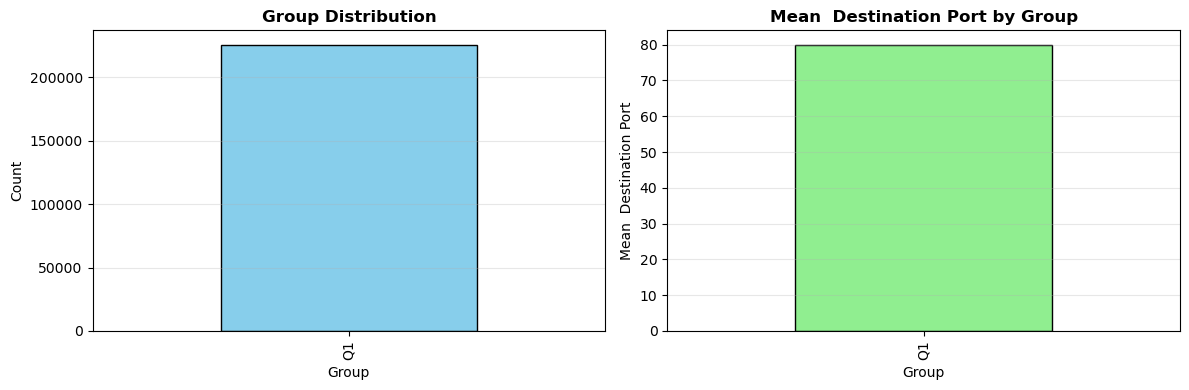


✓ Group by operations completed


In [12]:
# 8. GROUP BY OPERATIONS

numeric_final = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Group by first numeric column (binned)
quantile_bins = min(4, df_encoded[numeric_final[0]].nunique())
qcut_series = pd.qcut(df_encoded[numeric_final[0]], q=quantile_bins, duplicates='drop')
labels = [f'Q{i+1}' for i in range(len(qcut_series.cat.categories))]
df_encoded['bin_group'] = qcut_series.cat.rename_categories(labels)

if len(labels) < 4:
    print(f"Note: reduced to {len(labels)} quantile groups due to duplicate or tied values")

print("Group sizes:\n")
print(df_encoded['bin_group'].value_counts().sort_index())

print("\n\nMean by group:\n")
grouped_mean = df_encoded.groupby('bin_group')[numeric_final[0:3]].mean()
print(grouped_mean)

print("\n\nCount by group:\n")
grouped_count = df_encoded.groupby('bin_group')[numeric_final[0]].count()
print(grouped_count)

# Visualize groups
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df_encoded['bin_group'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Group Distribution', fontweight='bold')
plt.xlabel('Group')
plt.ylabel('Count')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
grouped_mean[numeric_final[0]].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f'Mean {numeric_final[0]} by Group', fontweight='bold')
plt.xlabel('Group')
plt.ylabel(f'Mean {numeric_final[0]}')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Group by operations completed")

# DATA VISUALIZATION
### Visualization helps in understanding feature distributions, relationships, and attack patterns. Graphical analysis improves interpretability and helps identify anomalies within the dataset.


Mean  Destination Port: 80.0000
Median  Destination Port: 80.0000
Min  Destination Port: 80.0000
Max  Destination Port: 80.0000
Skewness  Destination Port: 0.0000

Mean  Flow Duration: 5855151.3324
Median  Flow Duration: 1452362.0000
Min  Flow Duration: -1.0000
Max  Flow Duration: 21906338.0000
Skewness  Flow Duration: 1.2455


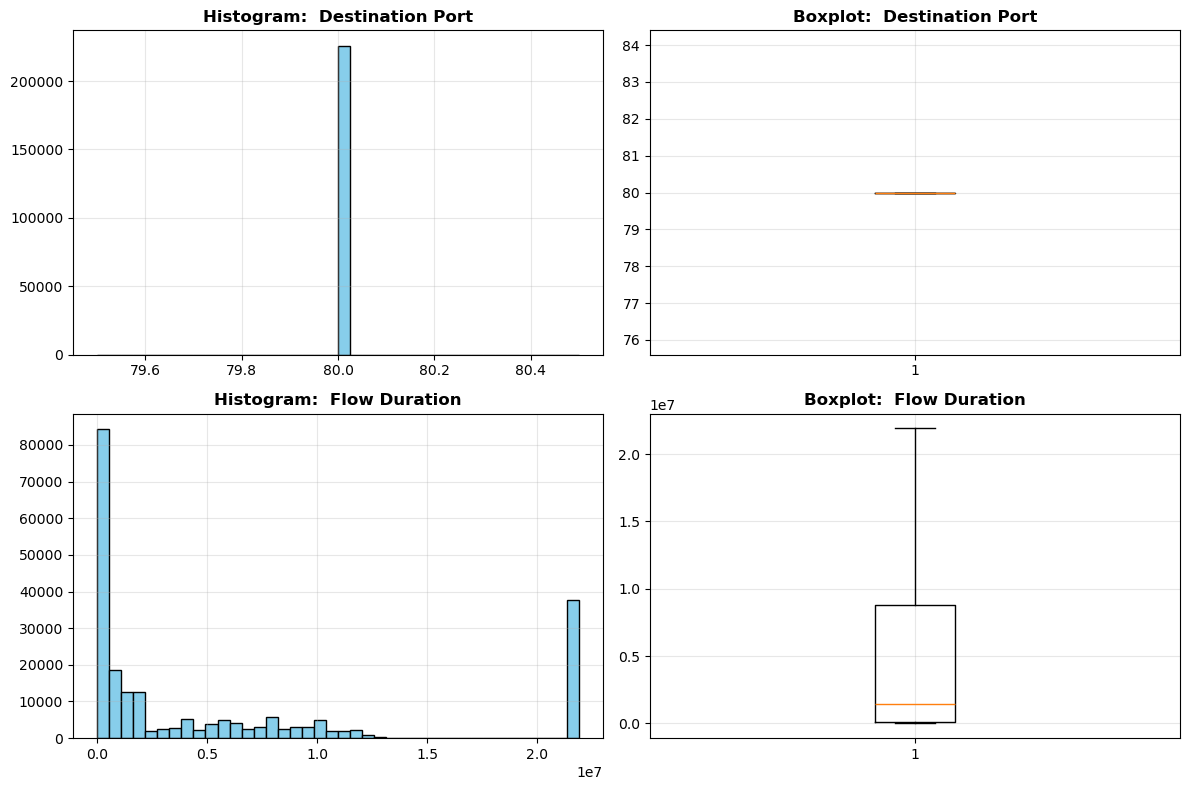

In [13]:
# 9. UNIVARIATE ANALYSIS

print(f"Mean {numeric_final[0]}: {df_encoded[numeric_final[0]].mean():.4f}")
print(f"Median {numeric_final[0]}: {df_encoded[numeric_final[0]].median():.4f}")
print(f"Min {numeric_final[0]}: {df_encoded[numeric_final[0]].min():.4f}")
print(f"Max {numeric_final[0]}: {df_encoded[numeric_final[0]].max():.4f}")
print(f"Skewness {numeric_final[0]}: {df_encoded[numeric_final[0]].skew():.4f}")

print(f"\nMean {numeric_final[1]}: {df_encoded[numeric_final[1]].mean():.4f}")
print(f"Median {numeric_final[1]}: {df_encoded[numeric_final[1]].median():.4f}")
print(f"Min {numeric_final[1]}: {df_encoded[numeric_final[1]].min():.4f}")
print(f"Max {numeric_final[1]}: {df_encoded[numeric_final[1]].max():.4f}")
print(f"Skewness {numeric_final[1]}: {df_encoded[numeric_final[1]].skew():.4f}")

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(df_encoded[numeric_final[0]], bins=40, color='skyblue', edgecolor='black')
plt.title(f'Histogram: {numeric_final[0]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.boxplot(df_encoded[numeric_final[0]])
plt.title(f'Boxplot: {numeric_final[0]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(df_encoded[numeric_final[1]], bins=40, color='skyblue', edgecolor='black')
plt.title(f'Histogram: {numeric_final[1]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.boxplot(df_encoded[numeric_final[1]])
plt.title(f'Boxplot: {numeric_final[1]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

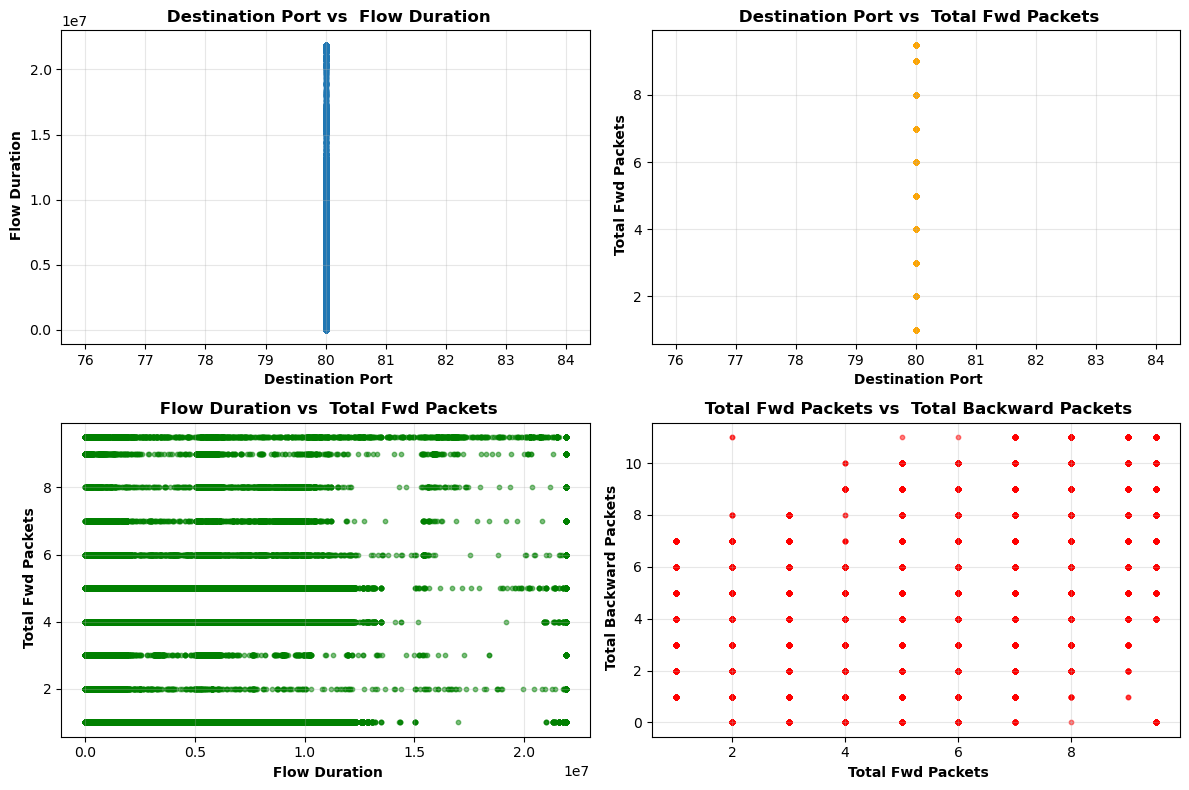

✓ Bivariate relationships plotted


In [14]:

# 10. BIVARIATE ANALYSIS

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.scatter(df_encoded[numeric_final[0]], df_encoded[numeric_final[1]], alpha=0.5, s=10)
plt.xlabel(numeric_final[0], fontweight='bold')
plt.ylabel(numeric_final[1], fontweight='bold')
plt.title(f'{numeric_final[0]} vs {numeric_final[1]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(df_encoded[numeric_final[0]], df_encoded[numeric_final[2]], alpha=0.5, s=10, color='orange')
plt.xlabel(numeric_final[0], fontweight='bold')
plt.ylabel(numeric_final[2], fontweight='bold')
plt.title(f'{numeric_final[0]} vs {numeric_final[2]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.scatter(df_encoded[numeric_final[1]], df_encoded[numeric_final[2]], alpha=0.5, s=10, color='green')
plt.xlabel(numeric_final[1], fontweight='bold')
plt.ylabel(numeric_final[2], fontweight='bold')
plt.title(f'{numeric_final[1]} vs {numeric_final[2]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(df_encoded[numeric_final[2]], df_encoded[numeric_final[3]], alpha=0.5, s=10, color='red')
plt.xlabel(numeric_final[2], fontweight='bold')
plt.ylabel(numeric_final[3], fontweight='bold')
plt.title(f'{numeric_final[2]} vs {numeric_final[3]}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Bivariate relationships plotted")

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


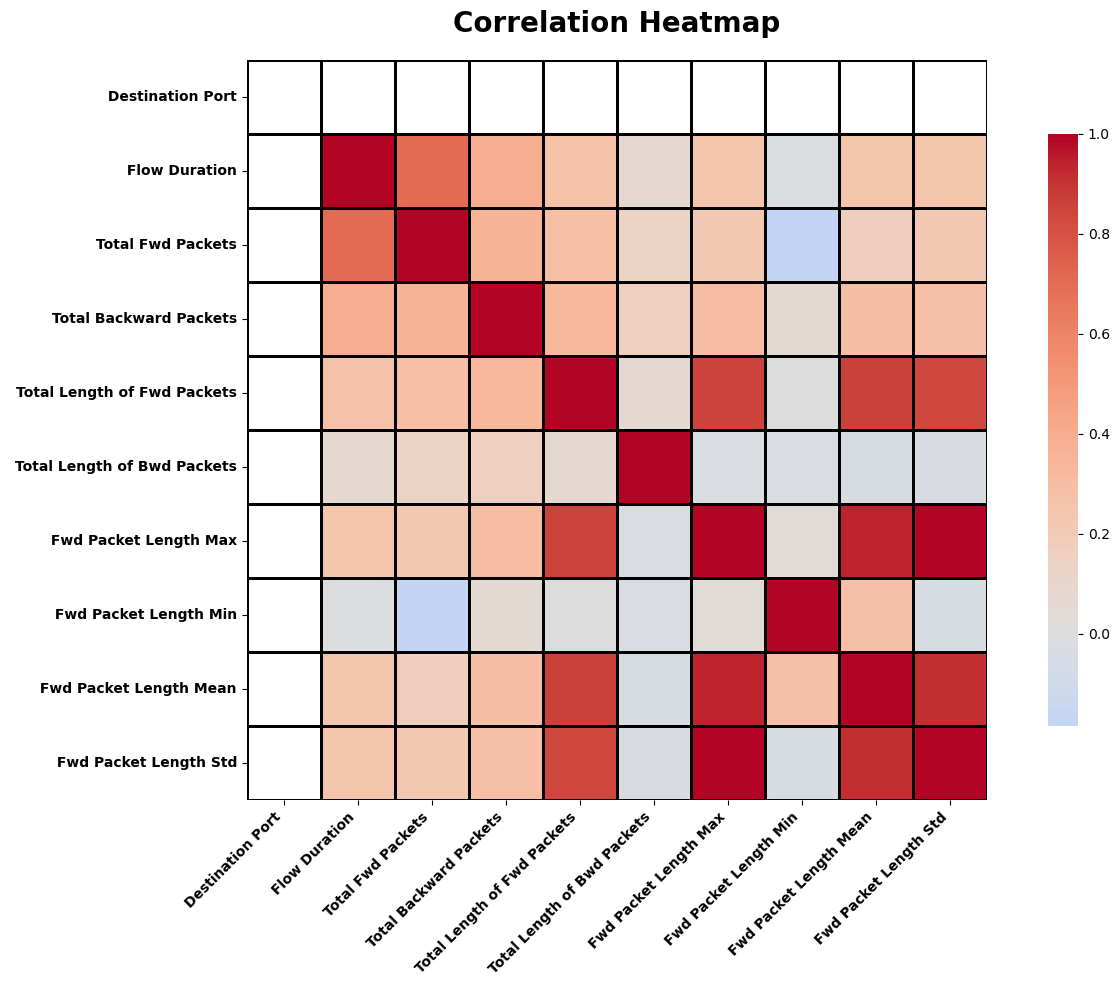

In [22]:
# 11. MULTIVARIATE ANALYSIS - CORRELATION

corr_matrix = df_encoded[numeric_final].corr()

# Heatmap Visualization
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix.iloc[0:10, 0:10],
    
    # Numbers inside heatmap
    annot=True,
    fmt='.2f',
    
    # Heatmap style
    cmap='coolwarm',
    center=0,
    
    # Borders
    linewidths=1,
    linecolor='black',
    
    # Square cells
    square=True,
    
    # Annotation styling (numbers inside boxes)
    annot_kws={
        "size": 11,
        "weight": "bold",
        "color": "white"
    },
    
    # Color bar size
    cbar_kws={"shrink": 0.8}
)

# Title
plt.title(
    'Correlation Heatmap',
    fontsize=20,
    fontweight='bold',
    pad=20
)

# X-axis labels
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

# Y-axis labels
plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Display plot
plt.show()

# Inetrpretation 
### Visualization techniques showed that the dataset contains highly skewed distributions, imbalanced attack classes, and strong relationships between certain network traffic features.

#### The correlation heatmap showed strong positive and negative relationships among several network traffic features. Highly correlated features indicate redundant information, which can be reduced using PCA.Strong positive correlation means both features increase together, while strong negative correlation means one feature increases as the other decreases.

# FEATURE ENGINEERING
### Feature engineering involves creating new meaningful features from existing data to improve model performance.

In [16]:
# 12. FEATURE ENGINEERING

df_features = df_encoded.copy()

# Log transformations
df_features[f'{numeric_final[0]}_log'] = np.log1p(df_features[numeric_final[0]])
df_features[f'{numeric_final[1]}_log'] = np.log1p(df_features[numeric_final[1]])
print(f"✓ Created log features")

# Squared features
df_features[f'{numeric_final[0]}_squared'] = df_features[numeric_final[0]] ** 2
df_features[f'{numeric_final[1]}_squared'] = df_features[numeric_final[1]] ** 2
print(f"✓ Created squared features")

# Interaction feature
df_features[f'{numeric_final[0]}_x_{numeric_final[1]}'] = df_features[numeric_final[0]] * df_features[numeric_final[1]]
print(f"✓ Created interaction feature")

# Aggregate features
df_features['mean_all'] = df_features[numeric_final].mean(axis=1)
df_features['std_all'] = df_features[numeric_final].std(axis=1)
print(f"✓ Created aggregate features")

print(f"\nNew shape: {df_features.shape}")
print(f"New features created: {df_features.shape[1] - df_encoded.shape[1]}")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


✓ Created log features
✓ Created squared features
✓ Created interaction feature
✓ Created aggregate features

New shape: (225741, 87)
New features created: 7


# Interpretation
### New traffic-based features were generated to improve the dataset representation and capture hidden network behavior patterns more effectively.

# FEATURE SCALING

## Feature scaling standardizes numerical values into a common range. Features with different scales can negatively affect algorithms such as PCA and Neural Networks.

### Standardization transforms the data using:

#### Mean = 0
#### Standard Deviation = 1

In [17]:
# 13. SCALING & NORMALIZATION

numeric_to_scale = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Replace infinite values with NaN and impute with median before scaling
if df_features[numeric_to_scale].isin([np.inf, -np.inf]).any().any():
    print("Imputing infinite values in numeric features before scaling")
    df_features = df_features.replace([np.inf, -np.inf], np.nan)
    df_features[numeric_to_scale] = df_features[numeric_to_scale].fillna(df_features[numeric_to_scale].median())

# StandardScaler
scaler_std = StandardScaler()
df_standard = df_features.copy()
df_standard[numeric_to_scale] = scaler_std.fit_transform(df_features[numeric_to_scale])
print(f"StandardScaler applied")
print(f"  Mean: {df_standard[numeric_to_scale].mean().mean():.6f}")
print(f"  Std: {df_standard[numeric_to_scale].std().mean():.6f}")

# MinMaxScaler
scaler_mm = MinMaxScaler()
df_minmax = df_features.copy()
df_minmax[numeric_to_scale] = scaler_mm.fit_transform(df_features[numeric_to_scale])
print(f"\nMinMaxScaler applied")
print(f"  Min: {df_minmax[numeric_to_scale].min().min():.4f}")
print(f"  Max: {df_minmax[numeric_to_scale].max().max():.4f}")

# Use StandardScaler
df_scaled = df_standard.copy()
print(f"\n✓ Using StandardScaler for final dataset")
print(f"Shape: {df_scaled.shape}")


Imputing infinite values in numeric features before scaling
StandardScaler applied
  Mean: -0.000000
  Std: 0.848839

MinMaxScaler applied
  Min: 0.0000
  Max: 1.0000

✓ Using StandardScaler for final dataset
Shape: (225741, 87)


# Interpretation

### All numerical features were standardized using StandardScaler to improve PCA performance and stabilize machine learning algorithms.

# PRINCIPAL COMPONENT ANALYSIS (PCA)
### Principal Component Analysis (PCA) is a dimensionality reduction technique used to reduce the number of features while preserving maximum information.PCA transforms correlated features into smaller independent components called Principal Components.

Original features: 86
Principal components: 10

PC1: 0.253300 (25.33%)
PC2: 0.137198 (13.72%)
PC3: 0.102380 (10.24%)
PC4: 0.086973 (8.70%)
PC5: 0.044283 (4.43%)

✓ Components required for 95% variance: 10

PCA Component Loadings:

                                       PC1     PC2     PC3     PC4     PC5
 Destination Port                  -0.0000 -0.0000  0.0000  0.0000 -0.0000
 Flow Duration                      0.2071 -0.0410 -0.0191  0.1041  0.0470
 Total Fwd Packets                  0.1564  0.0450  0.0172  0.0832  0.1107
 Total Backward Packets             0.1202  0.0971  0.0509 -0.1378 -0.0349
Total Length of Fwd Packets         0.1137 -0.0665  0.0892 -0.2645  0.0487
...                                    ...     ...     ...     ...     ...
 Destination Port_squared          -0.0000 -0.0000  0.0000 -0.0000  0.0000
 Flow Duration_squared              0.2143 -0.0216 -0.0199  0.0878  0.0179
 Destination Port_x_ Flow Duration  0.2071 -0.0410 -0.0191  0.1041  0.0470
mean_all           

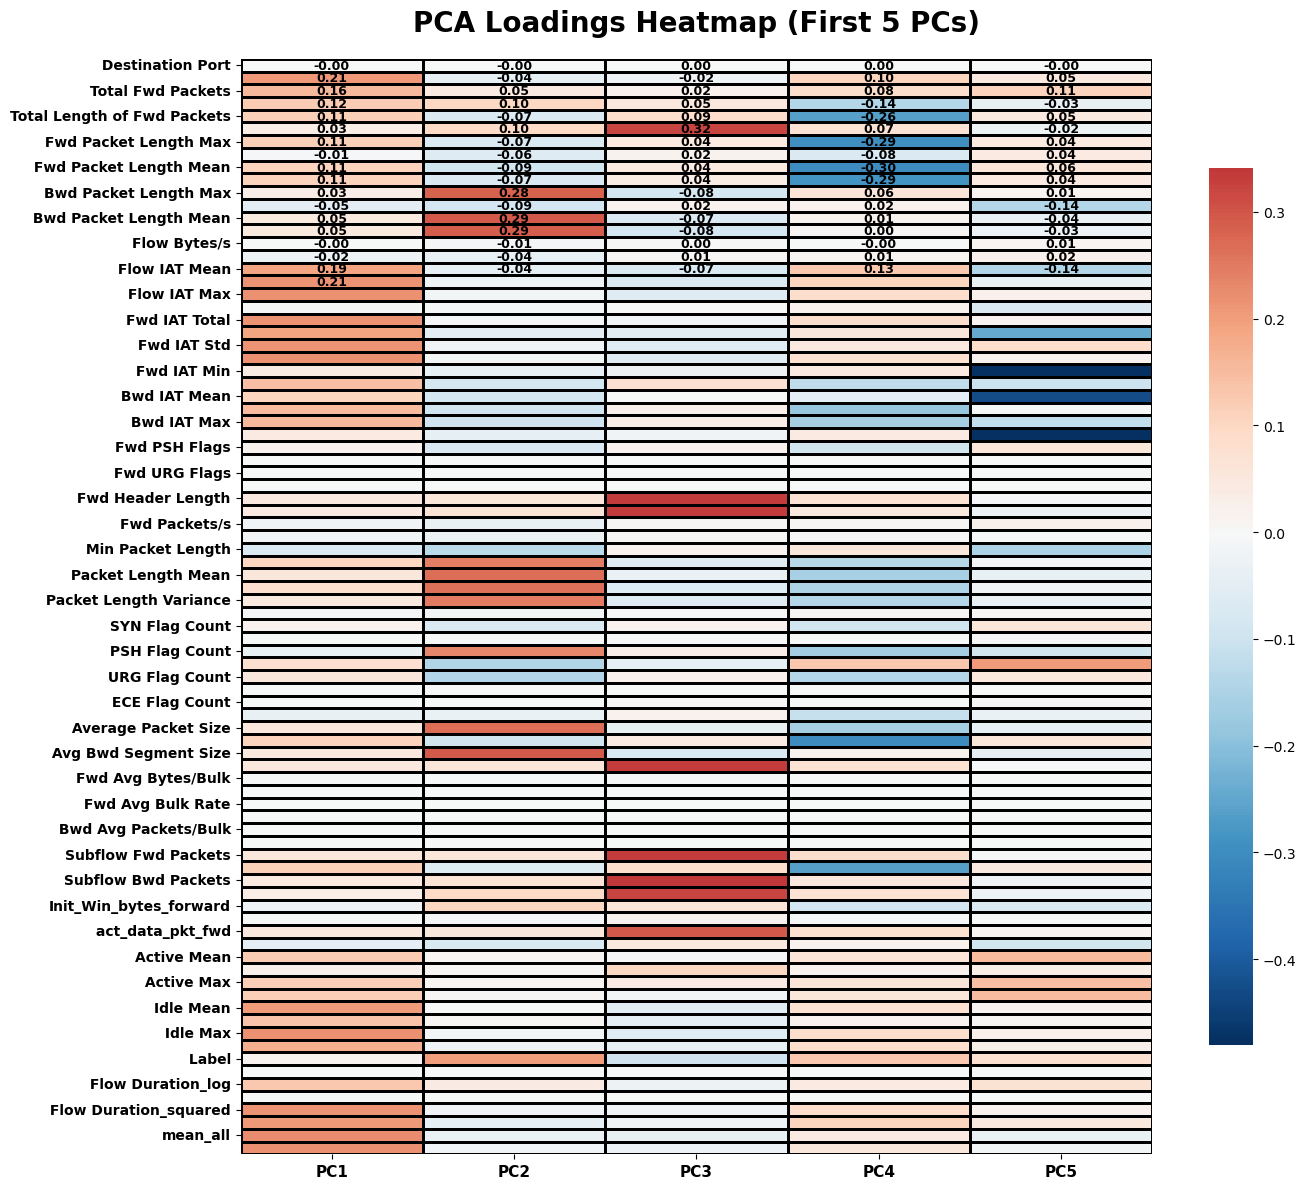


Interpretation:
• High absolute loading = Strong feature contribution
• Positive loading = Feature increases with PC
• Negative loading = Feature decreases with PC


In [23]:
# 14. PCA - DIMENSIONALITY REDUCTION & LOADINGS

numeric_to_scale = df_features.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_to_scale) < 2:
    raise ValueError("Not enough numeric features available for PCA.")

# Number of principal components
n_comp = min(10, len(numeric_to_scale))

# PCA model
pca = PCA(n_components=n_comp)

# Transform data
X_pca = pca.fit_transform(df_scaled[numeric_to_scale])

# PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)

print(f"Original features: {len(numeric_to_scale)}")
print(f"Principal components: {n_comp}\n")

# Explained variance
explained_variance = pca.explained_variance_ratio_

for i, var in enumerate(explained_variance[:5], start=1):
    print(f"PC{i}: {var:.6f} ({var*100:.2f}%)")

# Cumulative variance
cumsum = np.cumsum(explained_variance)

if (cumsum >= 0.95).any():
    n_95 = np.argmax(cumsum >= 0.95) + 1
else:
    n_95 = n_comp

print(f"\n✓ Components required for 95% variance: {n_95}")

# PCA Loadings
loadings = pca.components_.T

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=numeric_to_scale
)

print("\nPCA Component Loadings:\n")
print(loadings_df.iloc[:, :5].round(4))

# Beautiful Heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    loadings_df.iloc[:, :5],

    # Show values inside boxes
    annot=True,
    fmt='.2f',

    # Color theme
    cmap='RdBu_r',
    center=0,

    # Borders
    linewidths=1,
    linecolor='black',

    # Annotation style
    annot_kws={
        "size": 9,
        "weight": "bold",
        "color": "black"
    },

    # Color bar
    cbar_kws={"shrink": 0.8}
)

# Title
plt.title(
    'PCA Loadings Heatmap (First 5 PCs)',
    fontsize=20,
    fontweight='bold',
    pad=20
)

# X-axis styling
plt.xticks(
    fontsize=11,
    fontweight='bold',
    rotation=0
)

# Y-axis styling
plt.yticks(
    fontsize=10,
    fontweight='bold',
    rotation=0
)

# Layout
plt.tight_layout()

# Show plot
plt.show()

print("\nInterpretation:")
print("• High absolute loading = Strong feature contribution")
print("• Positive loading = Feature increases with PC")
print("• Negative loading = Feature decreases with PC")

# Interpretation
### The dataset originally contained many correlated features. PCA successfully reduced the dimensionality while preserving most of the dataset variance.

### The explained variance ratio showed how much information each principal component retained from the original dataset.

 # FEATURE SELECTION
 ### Feature selection identifies the most important features related to attack classification. Removing irrelevant features improves model accuracy and reduces computational complexity.SelectKBest with ANOVA F-score is commonly used to rank features based on importance.

FEATURE SELECTION USING SELECTKBEST



/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 0 31 32 33 49 56 57 58 59 60 61 79 81] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 Selected Features:

Index(['Bwd Packet Length Max', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', ' Min Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' URG Flag Count', ' Average Packet Size',
       ' Avg Bwd Segment Size', ' Label'],
      dtype='object')

Top Feature Scores:

                    Feature         Score
78                    Label  1.510979e+17
10    Bwd Packet Length Max  2.721402e+05
54     Avg Bwd Segment Size  1.291759e+05
12   Bwd Packet Length Mean  1.291759e+05
13    Bwd Packet Length Std  1.121676e+05
48           URG Flag Count  6.166469e+04
40       Packet Length Mean  5.869756e+04
52      Average Packet Size  5.843390e+04
41        Packet Length Std  5.534735e+04
38        Min Packet Length  5.045569e+04


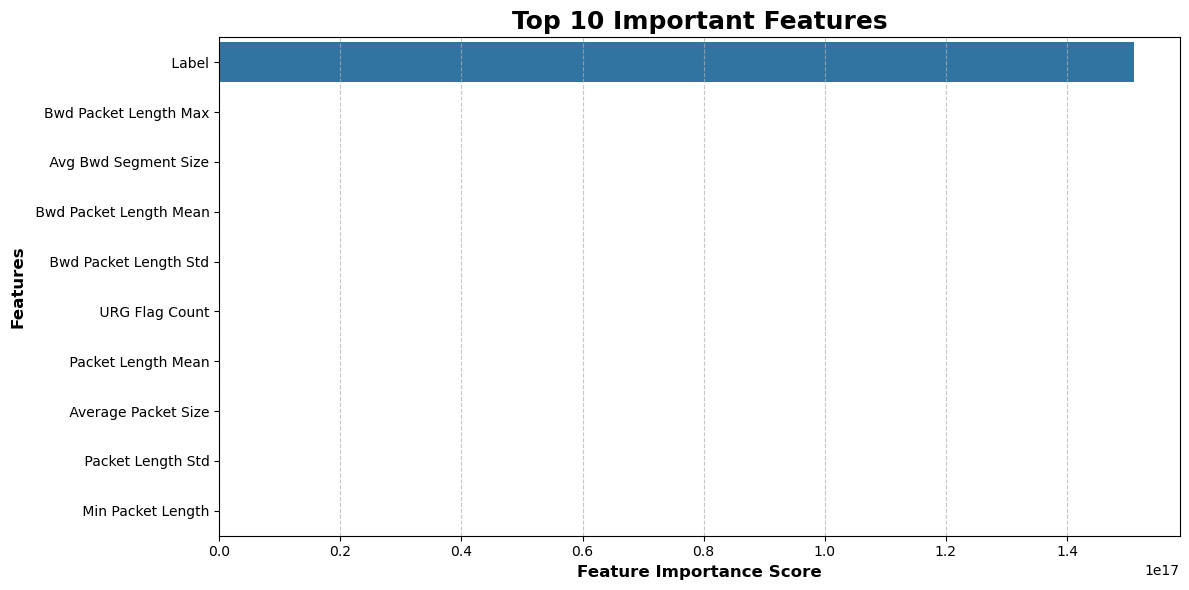


✓ Feature selection completed successfully


In [25]:
# 15. FEATURE SELECTION

from sklearn.feature_selection import SelectKBest, f_classif

print("FEATURE SELECTION USING SELECTKBEST\n")

# Features
X = df_scaled[numeric_to_scale]

# Target column (CICIDS2017 usually has space before Label)
y = df_encoded[' Label']

# Select top features
k = 10

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_selected = selector.fit_transform(X, y)

# Selected feature names
selected_features = X.columns[selector.get_support()]

# Feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

# Sort scores
feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)

print(f"Top {k} Selected Features:\n")
print(selected_features)

print("\nTop Feature Scores:\n")
print(feature_scores.head(10))

# Visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Score',
    y='Feature',
    data=feature_scores.head(10)
)

plt.title(
    'Top 10 Important Features',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Feature Importance Score',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

print("\n✓ Feature selection completed successfully")

# Interpretation
### Feature selection successfully identified the most important cybersecurity traffic features responsible for distinguishing benign traffic from DDoS attack traffic.The feature importance visualization highlighted the top contributing features used for attack detection.

# CONCLUSION

#### In this project, the CICIDS2017 cybersecurity dataset was analyzed using preprocessing, visualization, PCA, and feature selection techniques. The dataset contained real-world network traffic with missing values, noisy records, outliers, and imbalanced attack classes.

#### Data cleaning and preprocessing improved the quality of the dataset and prepared it for analytical and machine learning tasks. Visualization techniques helped in understanding attack distributions, traffic behavior, and feature relationships.

#### Correlation analysis revealed strong relationships among several network traffic features. Principal Component Analysis (PCA) successfully reduced dimensionality while retaining most of the important information from the dataset.

#### Feature engineering and feature selection further improved the dataset by identifying the most significant features responsible for DDoS attack detection.

#### Overall, the project demonstrated that preprocessing, dimensionality reduction, and feature selection are highly important for cybersecurity analytics and intrusion detection systems. The analysis provides a strong foundation for future machine learning and deep learning models such as Artificial Neural Networks (ANN), Random Forest, Support Vector Machines (SVM), and other intrusion detection techniques.

#### The project also highlights the importance of data preprocessing in handling real-world cybersecurity datasets that contain noise, missing values, outliers, and redundant information.